# Making a cutout from the full science mosaic

An essential component in preprocessing is creating a cutout of the system of interest from a full science mosaic. Through the `ImageCutout` class, `dolphin` provides a user-friendly interface for making such cutouts and a helper function to obtain initial coordinate guesses. 

In order to initialize the `ImageCutout` class, the full science image path must be provided, ending in `.fits`. For HST data, an additional file containing the weight information must also be provided, ending in `.fits`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from dolphin.ai import Vision
from dolphin.preprocessing.image_cutout import ImageCutout

io_directory = "../io_directory_example"
lens_name = "lensed_quasar_3"
data_band = "F814W"
full_image_file = f"../io_directory_example/full_image_{lens_name}_{data_band}.fits"
weight_image_file = f"../io_directory_example/weight_image_{lens_name}_{data_band}.fits"

image_cutout = ImageCutout(
    io_directory=io_directory,
    lens_name=lens_name,
    data_band=data_band,
    instrument="HST",
    full_image_file=full_image_file,
    weight_image_file=weight_image_file,
)

To visualize the full image, we can call `plot_full_image()`:

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/image_cutout.py:88: RuntimeWarning: invalid value encountered in log10
  plt_data = np.log10(data_full)


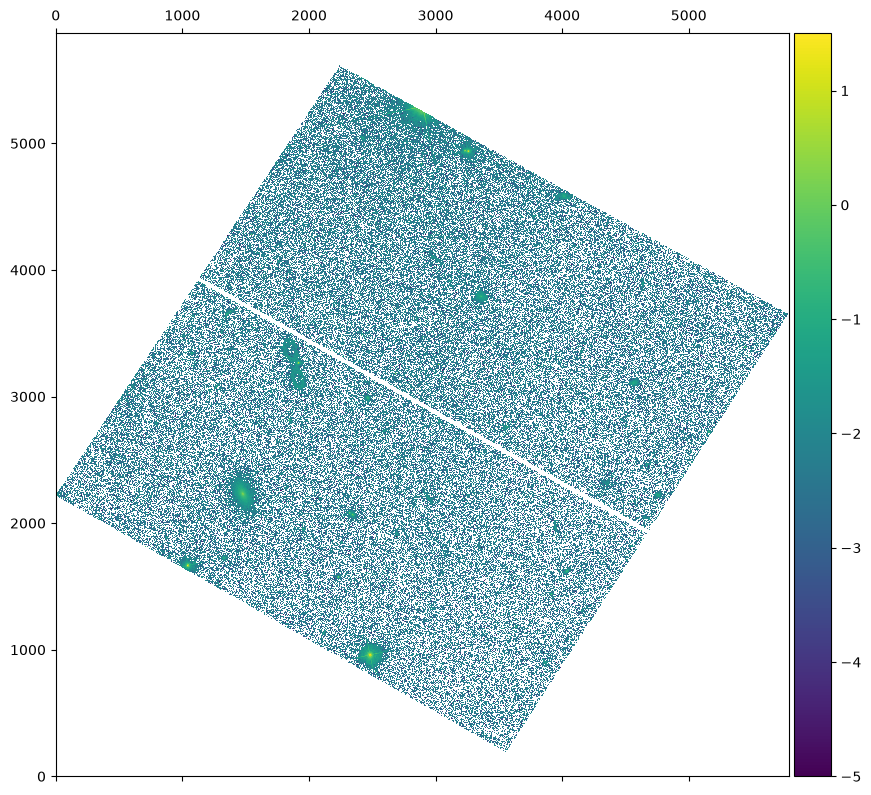

In [2]:
image_cutout.plot_full_image(vmin=-5)

To generate a cutout from the science image, we call `make_image_cutout()`. By default, the cutout will be centered at the target RA and DEC.

Target RA = 121.598667 deg
Target DEC = 20.108739 deg


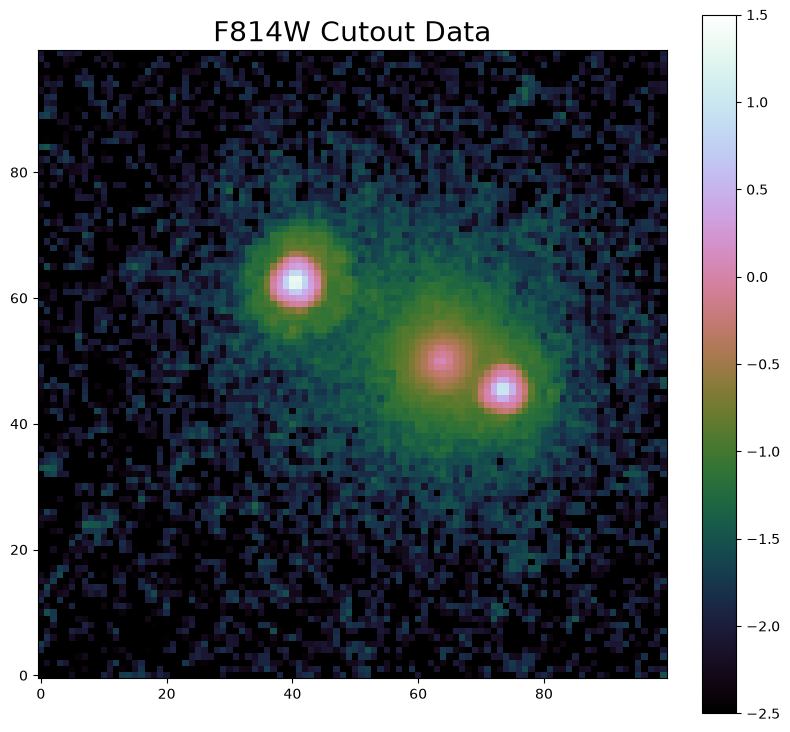

In [3]:
image_cutout.make_image_cutout(cutout_scale=100, vmin=-2.5, save=False)

To alter the center of the cutout, one can provide a tuple containing a shift in RA (east) and DEC (north) in arcseconds through the parameter `center_shift_arcsec`.

There are two ways of propagating noise into the modeling process, determined by the `use_noise_map` argument. If `True`, a cutout of the calculated per-pixel noise is saved in `kwargs_data` as `noise_map`. If `False`, the scalar `background_rms` determined by `photutils` is used instead, together with the `exposure_time` from the image header, to estimate the Poisson noise from the image data.

The function also contains a helper script to make masks around specified regions of the cutout. The three different mask options are `circle`, `square`, and `ellipse`. The masks can be stacked in an array of dictionaries to remove an arbitrary collection of regions from a candidate image. To invert the boolean logic of a specific mask components (for example, to change the logic from being `True` inside a region to `False` inside that same region), the key `"invert": True` must be present in that dictionary.

`make_image_cutout()` also creates all `dolphin` data arguments that are required: `image_data`, `ra_at_xy_0`, `dec_at_xy_0`, `transform_pix2angle`, `exposure_time`, and either `background_rms` or `noise_map`, depending on the specified type with `use_noise_map`.

To save all of the above in the expected `dolphin` location, toggle `save=True`.

Target RA = 121.598667 deg
Target DEC = 20.108739 deg
Cutout RA = 121.598548 deg
Cutout DEC = 20.108739 deg


/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/image_cutout.py:251: RuntimeWarning: divide by zero encountered in log10
  np.log10(noise_map * mask),


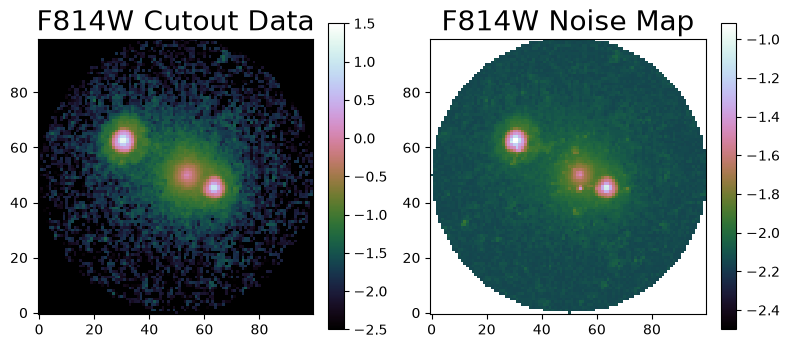

In [2]:
# create a circular mask around the edge
kwargs_mask = [{"type": "circle", "center": (50, 50), "radius": 50, "invert": False}]

image_cutout.make_image_cutout(
    cutout_scale=100,
    center_shift_arcsec=(-0.4, 0.0),
    vmin=-2.5,
    kwargs_mask=kwargs_mask,
    use_noise_map=True,
    save=True,
)

# Initial Coordinate Guessses

We encourage users to use the `dolphin` AI Segmentation workflow to establish initial coordinate guesses for the lens centroid, satellite centroids (if applicable), and quasar image positions (if applicable). Using the AI workflow helps streamline the initial setup of a lens model and is one of the notable features of `dolphin`'s automation capabilities. Here, we will show a quick example of the neural network segmentation, and refer the user to [Example of full automation with AI.ipynb](https://github.com/ajshajib/dolphin/blob/main/notebooks/Example%20of%20full%20auomation%20with%20AI.ipynb) for a more detailed example.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_92972/3986056650.py:8: RuntimeWarning: invalid value encountered in log10
  axes[0].imshow(np.log10(image), origin="lower", cmap="cubehelix")
/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_92972/3986056650.py:18: RuntimeWarning: invalid value encountered in log10
  axes[2].matshow(np.log10(image), origin="lower", cmap="cubehelix")


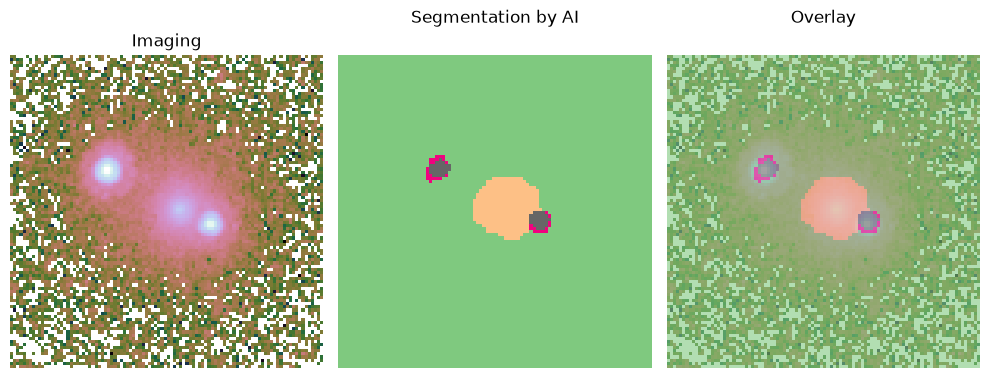

In [6]:
vision = Vision(io_directory_path=io_directory, source_type="quasar")
segementation = vision.create_segmentation_for_single_lens(lens_name, data_band)

image = vision.get_image_data(lens_name, data_band).get_image()

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(np.log10(image), origin="lower", cmap="cubehelix")
axes[0].set_title("Imaging")
axes[0].axis("off")

cmap = "Accent"
# use qualitaive cmap for the segmentation plot
axes[1].matshow(segementation, origin="lower", cmap=cmap)
axes[1].set_title("Segmentation by AI")
axes[1].axis("off")

axes[2].matshow(np.log10(image), origin="lower", cmap="cubehelix")
axes[2].matshow(segementation, origin="lower", cmap=cmap, alpha=0.6)
axes[2].set_title("Overlay")
axes[2].axis("off")

fig.tight_layout()

For more complex systems in which the neural network struggles, we provide an interactive helper function, named `get_angular_coordinates()`, to determine initial guess coordinates. Calling the function initiliazes an interactive Jupyter cell, where the user can click on any pixel and have that pixel display the RA and DEC from the cutout center, as expected by `dolphin` and `lenstronomy` for initial coordinate guesses.

/Users/rbrady0110/gits/dolphin/dolphin/preprocessing/image_cutout.py:322: RuntimeWarning: invalid value encountered in log10
  np.log10(image_data),


Output()

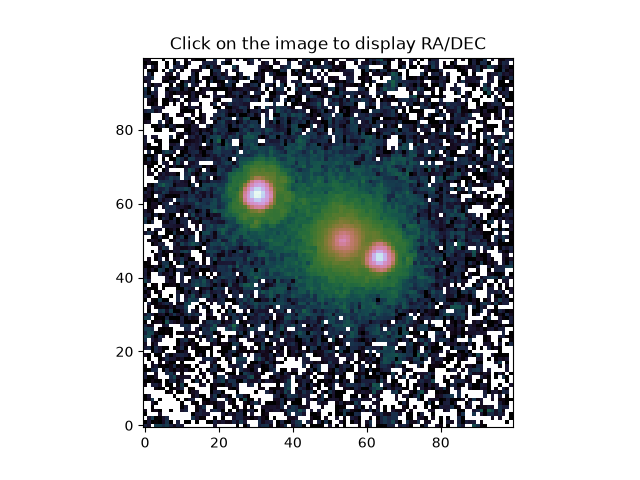

In [5]:
%matplotlib widget

fig = image_cutout.get_angular_coordinates(vmin=-2.5)

Upon clicking on the image, `get_angular_coordinates()` will print out the converted RA/DEC pixel values relative to the center RA/DEC, after which the user can copy those values into the respective configuration file location (as discussed in [Example for lensed quasar.ipynb](https://github.com/ajshajib/dolphin/blob/main/notebooks/Example%20for%20lensed%20quasar.ipynb)).